In [151]:
from google.colab import files
uploaded = files.upload()


Saving Human_Development_Index_Dataset.csv to Human_Development_Index_Dataset.csv


In [152]:
uploaded.keys()


dict_keys(['Human_Development_Index_Dataset.csv'])

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots show in notebook
%matplotlib inline


In [154]:
import pandas as pd

df = pd.read_csv("Human_Development_Index_Dataset.csv", encoding="latin1")
df.head()


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


In [155]:
# Column names and data types
df.info()

# Check unique years available
sorted(df["year"].dropna().unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6798 entries, 0 to 6797
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6798 non-null   int64  
 1   iso3                       6798 non-null   object 
 2   country                    6798 non-null   object 
 3   year                       6798 non-null   int64  
 4   hdi                        6171 non-null   float64
 5   life_expectancy            6798 non-null   float64
 6   pop_millions               6798 non-null   float64
 7   hdi_f                      5014 non-null   float64
 8   hdi_m                      5014 non-null   float64
 9   life_expec_f               6798 non-null   float64
 10  life_expec_m               6798 non-null   float64
 11  expec_yr_school            6550 non-null   float64
 12  expec_yr_school_f          6270 non-null   float64
 13  expec_yr_school_m          6270 non-null   float

[np.int64(1990),
 np.int64(1991),
 np.int64(1992),
 np.int64(1993),
 np.int64(1994),
 np.int64(1995),
 np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022)]

Basic Cleaning Function

In [156]:
def clean_hdi_dataframe(raw: pd.DataFrame) -> pd.DataFrame:
    d = raw.copy()

    # Drop useless index-like column if present
    if "Unnamed: 0" in d.columns:
        d = d.drop(columns=["Unnamed: 0"])

    # Replace common "missing" symbols with NaN
    d = d.replace({"–": np.nan, "—": np.nan, "-": np.nan})

    # Strip whitespace in country names
    if "country" in d.columns:
        d["country"] = d["country"].astype(str).str.strip()

    # Ensure year is numeric
    if "year" in d.columns:
        d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")

    # Force these to numeric (important for tasks)
    numeric_cols = ["hdi", "gross_inc_percap", "life_expectancy", "gender_development"]
    for c in numeric_cols:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    # Remove duplicate rows
    d = d.drop_duplicates()

    return d

df_clean = clean_hdi_dataframe(df)
df_clean.shape


(6798, 29)

PROBLEM 1A — Single Year (2022)

Task 1: Extract Latest Year

In [157]:
# Identify unique years
sorted(df["year"].dropna().unique())


[np.int64(1990),
 np.int64(1991),
 np.int64(1992),
 np.int64(1993),
 np.int64(1994),
 np.int64(1995),
 np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022)]

In [158]:
# Filter dataset to include only observations from year 2022
hdi_2022_df = df[df["year"] == 2022].copy()


In [159]:
# Save the filtered dataframe as hdi_2022_df for use in subsequent tasks
hdi_2022_df.to_csv('hdi_2022_df.csv', index=False)

Task 2: Data Exploration

In [160]:
# Display the first 10 rows of the 2022 dataset
hdi_2022_df.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [161]:
# Display number of rows and columns
print("Number of rows:", hdi_2022_df.shape[0])
print("Number of columns:", hdi_2022_df.shape[1])


Number of rows: 206
Number of columns: 30


In [162]:
# List all column names and their data types
hdi_2022_df.dtypes


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


Task 3: Missing Values & Data Cleaning

In [163]:
# Check missing values in each column
hdi_2022_df.isna().sum().sort_values(ascending=False)


,0
mat_footprint_percap_tons,41
gender_inequality,29
secondary_education_m_%,17
secondary_education_f_%,17
hdi_m,13
hdi_f,13
gender_development,13
gross_inc_percap_m,13
gross_inc_percap_f,13
labour_participation_f_%,12


In [164]:
# Remove rows where HDI is missing (essential for analysis)
hdi_2022_df = hdi_2022_df.dropna(subset=["hdi"]).copy()

print("Shape after removing missing HDI:", hdi_2022_df.shape)


Shape after removing missing HDI: (204, 30)


Task 4: Basic Statistics

In [165]:
# Mean, median, and standard deviation of HDI
mean_hdi = hdi_2022_df["hdi"].mean()
median_hdi = hdi_2022_df["hdi"].median()
std_hdi = hdi_2022_df["hdi"].std()

# Print the results in the required format
print(f"Mean: {mean_hdi:.4f}")
print(f"Median: {median_hdi:.4f}")
print(f"Standard Deviation: {std_hdi:.4f}")


Mean: 0.7229
Median: 0.7395
Standard Deviation: 0.1530


In [166]:
# Country with highest HDI
highest_hdi = hdi_2022_df.loc[hdi_2022_df["hdi"].idxmax(), ["country", "hdi"]]

# Country with lowest HDI
lowest_hdi = hdi_2022_df.loc[hdi_2022_df["hdi"].idxmin(), ["country", "hdi"]]

# Print the results in the required format
print(f"Country with highest HDI: {highest_hdi['country']}, HDI: {highest_hdi['hdi']:.4f}")
print(f"Country with lowest HDI: {lowest_hdi['country']}, HDI: {lowest_hdi['hdi']:.4f}")


Country with highest HDI: Switzerland, HDI: 0.9670
Country with lowest HDI: Somalia, HDI: 0.3800


Task 5: Filtering and Sorting

In [167]:
# Filter countries with HDI greater than 0.800
high_hdi_df = hdi_2022_df[hdi_2022_df["hdi"] > 0.800].copy()

# Sort by Gross National Income per Capita in descending order
high_hdi_df = high_hdi_df.sort_values("gross_inc_percap", ascending=False)

# Display top 10 countries
high_hdi_df[["country", "hdi", "gross_inc_percap"]].head(10)


,country,hdi,gross_inc_percap
3332,Liechtenstein,0.942,146673.24150
4718,Qatar,0.875,95944.37754
5213,Singapore,0.949,88761.14559
2705,Ireland,0.950,87467.51391
3398,Luxembourg,0.927,78554.23640
6104,United Arab Emirates,0.937,74103.71494
5609,Switzerland,0.967,69432.78669
4322,Norway,0.966,69189.76165
6170,United States,0.927,65564.93798
2474,"Hong Kong, China (SAR)",0.956,62485.50516


Task 6: Adding HDI Category Column

In [168]:
# Define HDI categories based on UNDP thresholds
bins = [-float("inf"), 0.550, 0.700, 0.800, float("inf")]
labels = ["Low", "Medium", "High", "Very High"]

hdi_2022_df["HDI Category"] = pd.cut(
    hdi_2022_df["hdi"],
    bins=bins,
    labels=labels,
    right=False
)

# Verify classification
hdi_2022_df["HDI Category"].value_counts()


,count
HDI Category,
Very High,71
High,54
Medium,44
Low,35


In [169]:
# Save the updated dataframe
hdi_2022_df.to_csv("HDI category added.csv", index=False)

print("File saved: HDI category added.csv")


File saved: HDI category added.csv


Problem – 1B – HDI Visualization and Trend Analysis (2020–2022)

Task 1: Data Extraction and Saving

In [170]:
# Filter dataset for years 2020, 2021, and 2022
hdi_2020_2022 = df[df["year"].isin([2020, 2021, 2022])].copy()

# Check shape
hdi_2020_2022.shape


(618, 30)

In [171]:
hdi_2020_2022.to_csv("HDI problem1B.csv", index=False)
print("Saved: HDI problem1B.csv")


Saved: HDI problem1B.csv


Task 2: Data Cleaning

In [172]:
# Checking for missing values
hdi_2020_2022[["country", "year", "hdi"]].isna().sum()

,0
country,0
year,0
hdi,8


In [173]:
# Inspect dataset for inconsistent or misspelled country names
unique_countries = hdi_2022_df['country'].unique()
print("Unique countries in the dataset:")
print(unique_countries)


Unique countries in the dataset:
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Congo (Democratic Republic of the)' 'Costa Rica'
 "Côte d'Ivoire" 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini (Kingdom of)'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hong Kong, China (SAR)' 'Hungary' 'Iceland' 'India'
 '

In [174]:
# Example corrections (if needed)
country_corrections = {
    'United States of America': 'USA',  # Correcting an example name
    'United Kingdom': 'UK'
    # Add more corrections as needed
}

# Apply the corrections
hdi_2022_df['country'] = hdi_2022_df['country'].replace(country_corrections)


In [175]:
# Check for duplicate rows
duplicates = hdi_2022_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicate rows
hdi_2022_df = hdi_2022_df.drop_duplicates()


Number of duplicate rows: 0


In [176]:
# Inspect columns that are stored as text but should be numeric
numeric_columns_as_text = hdi_2022_df.select_dtypes(include=['object']).columns
print("Columns stored as text (but expected to be numeric):")
print(numeric_columns_as_text)

# Convert the columns to numeric (e.g., 'gross_inc_percap')
hdi_2022_df['gross_inc_percap'] = pd.to_numeric(hdi_2022_df['gross_inc_percap'], errors='coerce')

Columns stored as text (but expected to be numeric):
Index(['iso3', 'country'], dtype='object')


In [177]:
# Handle special characters (e.g., "-" representing missing data)
hdi_2022_df.replace("-", pd.NA, inplace=True)


In [178]:
# Drop rows where essential columns ('hdi', 'country', 'year') are missing
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi', 'country', 'year'])


In [179]:
hdi_2020_2022 = hdi_2020_2022.dropna(subset=["country", "year", "hdi"]).copy()

hdi_2020_2022.shape


(610, 30)

Task 3: Visualization Tasks:

A. Line Chart — HDI Trend (Country-Level):

<Figure size 900x600 with 0 Axes>

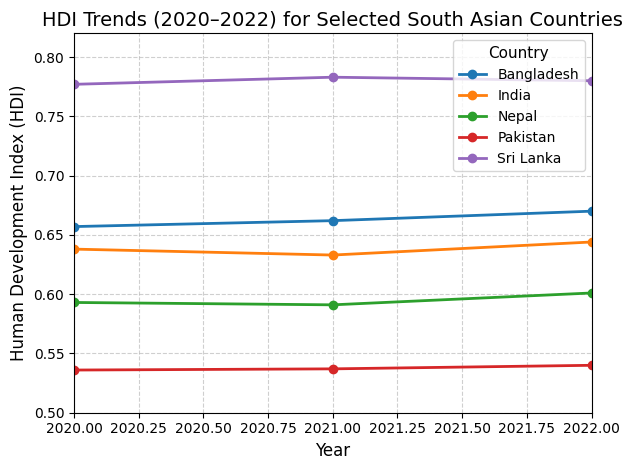

In [180]:
import matplotlib.pyplot as plt
import numpy as np

# Select five countries
countries = ["Nepal", "India", "Pakistan", "Bangladesh", "Sri Lanka"]

trend_df = hdi_2020_2022[hdi_2020_2022["country"].isin(countries)]

# Pivot data
pivot_df = trend_df.pivot(index="year", columns="country", values="hdi")

# Create plot
plt.figure(figsize=(9, 6))
pivot_df.plot(
    marker="o",
    linewidth=2,
    markersize=6
)

# Title and labels
plt.title("HDI Trends (2020–2022) for Selected South Asian Countries", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Human Development Index (HDI)", fontsize=12)

# ---- IMPORTANT PART: Fractional timestamps ----
x_ticks = np.arange(2020, 2023, 0.25)  # 2020.00 to 2022.75
plt.xticks(x_ticks)

# Axis limits
plt.xlim(2020, 2022)
plt.ylim(0.50, 0.82)

# Legend
plt.legend(title="Country", fontsize=10, title_fontsize=11)

# Grid
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()



B. Generate Visualizations:

Bar Chart: Average HDI by Region (2020–2022)

In [181]:
# Create region mapping (only required regions)
region_map = {
    "Nepal": "South Asia",
    "India": "South Asia",
    "Pakistan": "South Asia",
    "Bangladesh": "South Asia",
    "Sri Lanka": "South Asia",
    "Afghanistan": "South Asia",
    "Bhutan": "South Asia",
    "Maldives": "South Asia"
}

hdi_2020_2022["Region"] = hdi_2020_2022["country"].map(region_map)

region_df = hdi_2020_2022.dropna(subset=["Region"])


In [110]:
avg_region = region_df.groupby(["Region", "year"])["hdi"].mean().reset_index()

avg_region


,Region,year,hdi
0,South Asia,2020,0.637625
1,South Asia,2021,0.638625
2,South Asia,2022,0.642500


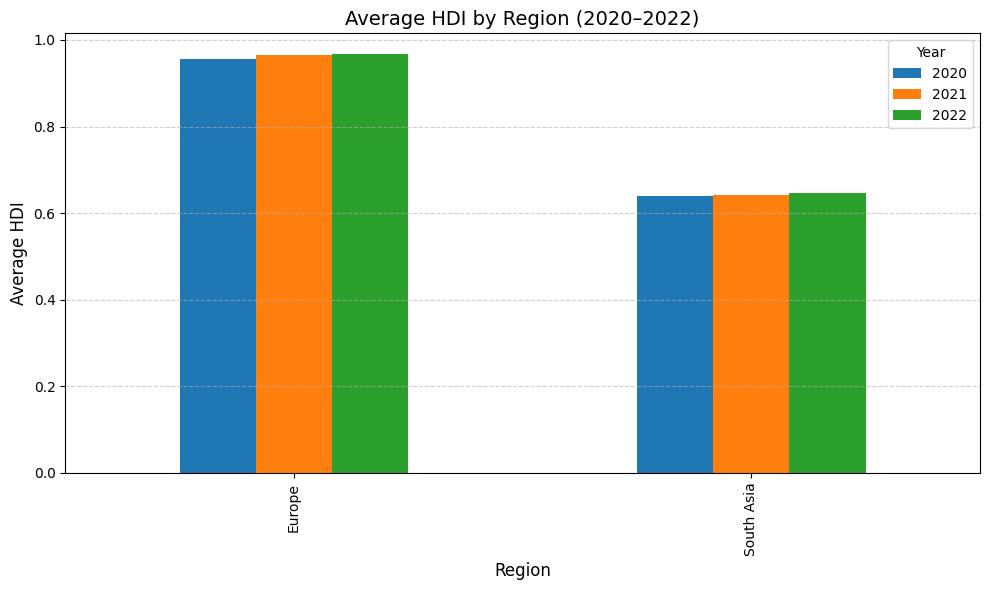

In [182]:
import matplotlib.pyplot as plt
import numpy as np
region_mapping = {
    "Nepal": "South Asia",
    "India": "South Asia",
    "Pakistan": "South Asia",
    "Bangladesh": "South Asia",
    "Sri Lanka": "South Asia",
    "Switzerland": "Europe",
    # Add more countries here...
}

# Add region column based on the country column
hdi_2020_2022['region'] = hdi_2020_2022['country'].map(region_mapping)

# Group data by Region and Year, then compute mean HDI
avg_hdi_region = (
    hdi_2020_2022.groupby(["region", "year"])["hdi"]
    .mean()
    .unstack()
)

# Plot the bar chart
avg_hdi_region.plot(kind='bar', figsize=(10, 6))

# Set titles and axis labels
plt.title("Average HDI by Region (2020–2022)", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average HDI", fontsize=12)

# Show the legend and grid
plt.legend(title="Year", fontsize=10)
plt.grid(True, axis='y', linestyle="--", alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()


Box Plot: HDI Distribution for 2020, 2021, and 2022

/tmp/ipython-input-3429350984.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[2020, 2021, 2022])


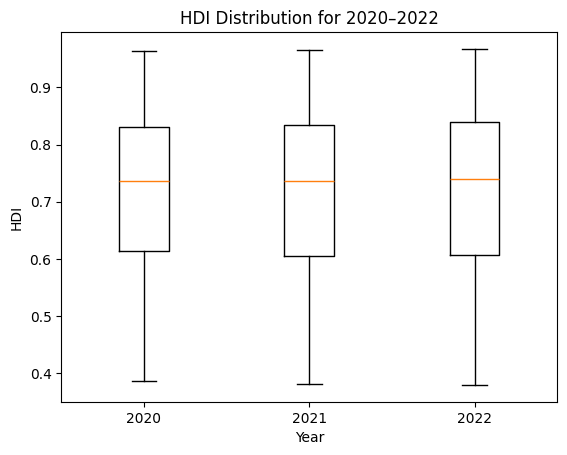

In [183]:
data = [
    hdi_2020_2022[hdi_2020_2022["year"] == 2020]["hdi"],
    hdi_2020_2022[hdi_2020_2022["year"] == 2021]["hdi"],
    hdi_2020_2022[hdi_2020_2022["year"] == 2022]["hdi"]
]

plt.boxplot(data, labels=[2020, 2021, 2022])
plt.title("HDI Distribution for 2020–2022")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.show()


Scatter Plot: HDI vs. GNI per Capita

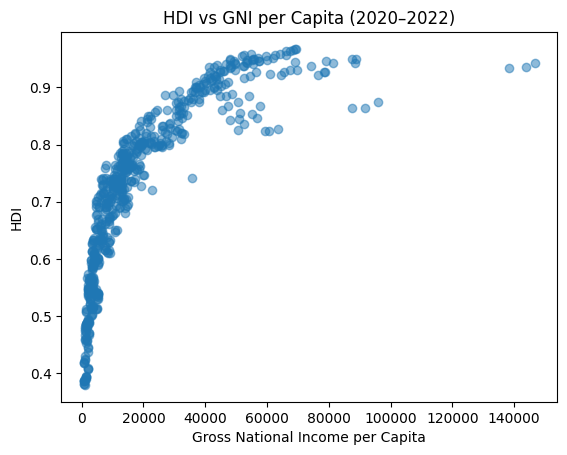

In [184]:
scatter_df = hdi_2020_2022.dropna(subset=["gross_inc_percap", "hdi"])

plt.scatter(scatter_df["gross_inc_percap"], scatter_df["hdi"], alpha=0.5)
plt.title("HDI vs GNI per Capita (2020–2022)")
plt.xlabel("Gross National Income per Capita")
plt.ylabel("HDI")
plt.show()


Short Analysis Question's Answers

- Several countries show gradual improvement in HDI from 2020 to 2022.
- Some countries experienced stagnation or slight decline, likely due to COVID-19 impacts.
- South Asia shows lower average HDI compared to global averages.
- The pandemic likely affected income, education, and life expectancy components of HDI.


Problem 2 — Advanced HDI Exploration

Task 1: Create South Asia Subset

In [185]:
south_asia_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "India",
    "Maldives",
    "Nepal",
    "Pakistan",
    "Sri Lanka"
]


In [186]:
south_asia_df = df[df["country"].isin(south_asia_countries)].copy()

south_asia_df.shape


(264, 30)

In [187]:
south_asia_df.to_csv("HDI SouthAsia.csv", index=False)
print("Saved: HDI SouthAsia.csv")


Saved: HDI SouthAsia.csv


Task 2: Composite Development Score

In [188]:
south_asia_df["Composite Score"] = (
    0.30 * south_asia_df["life_expectancy"] +
    0.30 * south_asia_df["gross_inc_percap"]
)


In [189]:
# Use latest year (2022) for ranking
sa_2022 = south_asia_df[south_asia_df["year"] == 2022].dropna(
    subset=["Composite Score"]
)

ranked_sa = sa_2022.sort_values("Composite Score", ascending=False)

ranked_sa[["country", "Composite Score", "hdi"]]


,country,Composite Score,hdi
3530,Maldives,5678.289357,0.762
5477,Sri Lanka,3592.832541,0.780
659,Bhutan,3209.130864,0.681
2573,India,2105.481239,0.644
461,Bangladesh,1975.446053,0.670
4388,Pakistan,1632.210427,0.540
4091,Nepal,1228.811605,0.601
32,Afghanistan,419.425420,0.462


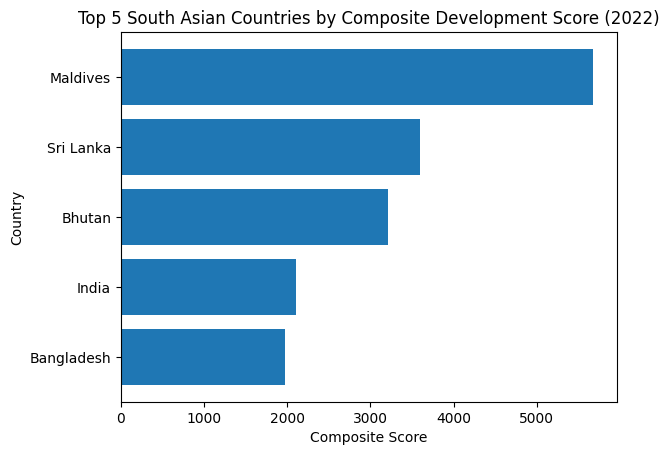

In [190]:
top5 = ranked_sa.head(5)

plt.barh(top5["country"], top5["Composite Score"])
plt.title("Top 5 South Asian Countries by Composite Development Score (2022)")
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()


Comparison of Composite Score and HDI Ranking:
       country  Composite_Rank  HDI_Rank  Composite Score    HDI
0     Maldives             1.0       2.0      5678.289357  0.762
1    Sri Lanka             2.0       1.0      3592.832541  0.780
2       Bhutan             3.0       3.0      3209.130864  0.681
3        India             4.0       5.0      2105.481239  0.644
4   Bangladesh             5.0       4.0      1975.446053  0.670
5     Pakistan             6.0       7.0      1632.210427  0.540
6        Nepal             7.0       6.0      1228.811605  0.601
7  Afghanistan             8.0       8.0       419.425420  0.462


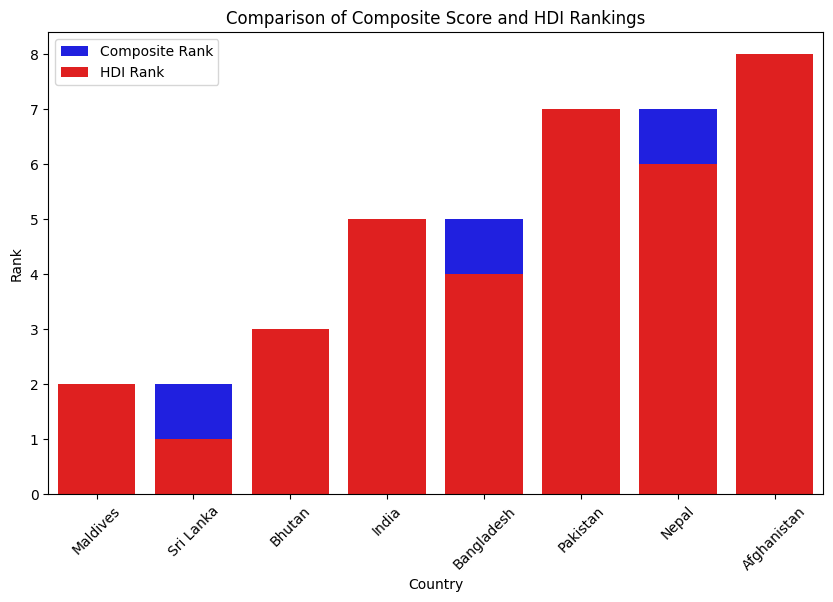

In [191]:
# Use the 'ranked_sa' DataFrame which contains both 'Composite Score' and 'hdi' for the latest year
composite_rank = ranked_sa[['country', 'Composite Score']].copy()
hdi_rank = ranked_sa[['country', 'hdi']].copy()

# Merge the Composite Score and HDI rankings
rank_comparison = pd.merge(composite_rank, hdi_rank, on='country', how='inner')

# Rename columns for better clarity
rank_comparison = rank_comparison.rename(columns={'Composite_Score': 'Composite Score', 'hdi': 'HDI'})

# Add rank columns for easier comparison
rank_comparison['Composite_Rank'] = rank_comparison['Composite Score'].rank(ascending=False)
rank_comparison['HDI_Rank'] = rank_comparison['HDI'].rank(ascending=False)

# Display the comparison
print("Comparison of Composite Score and HDI Ranking:")
print(rank_comparison[['country', 'Composite_Rank', 'HDI_Rank', 'Composite Score', 'HDI']])

# Optional: Plot the differences
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='Composite_Rank', data=rank_comparison, color='blue', label='Composite Rank')
sns.barplot(x='country', y='HDI_Rank', data=rank_comparison, color='red', label='HDI Rank')
plt.xlabel('Country')
plt.ylabel('Rank')
plt.title('Comparison of Composite Score and HDI Rankings')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Task 3: Outlier Detection

In [192]:
#Prepare data (latest year only)
# Use South Asia data for the latest year (2022)
sa_2022 = south_asia_df[south_asia_df["year"] == 2022].copy()

# Keep only required columns
sa_2022 = sa_2022.dropna(subset=["hdi", "gross_inc_percap"])

sa_2022[["country", "hdi", "gross_inc_percap"]]


,country,hdi,gross_inc_percap
32,Afghanistan,0.462,1335.205733
461,Bangladesh,0.670,6511.122178
659,Bhutan,0.681,10624.873880
2573,India,0.644,6950.526798
3530,Maldives,0.762,18846.792190
4091,Nepal,0.601,4025.554685
4388,Pakistan,0.540,5374.270423
5477,Sri Lanka,0.780,11899.498470


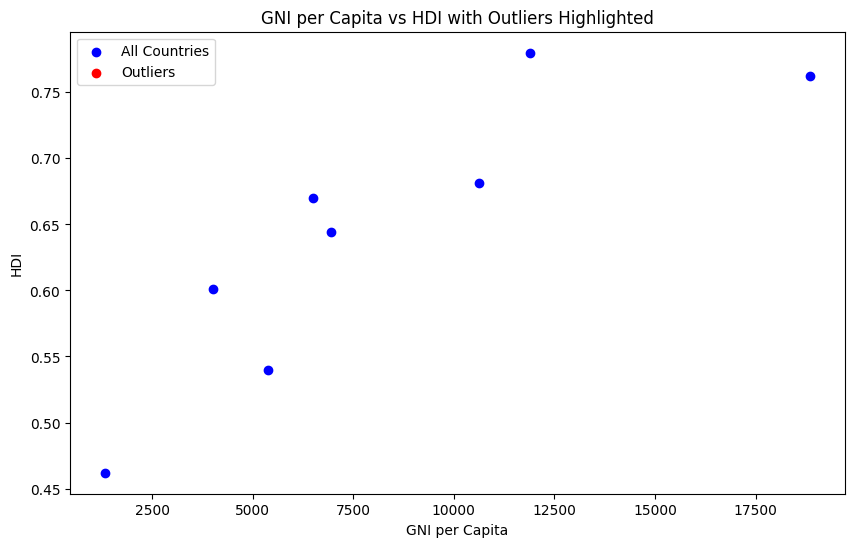

Outliers in HDI (below 0.4124999999999999 or above 0.8745):
Empty DataFrame
Columns: [country, hdi]
Index: []
Outliers in GNI per Capita (below -3822.566319999998 or above 19803.187835999997):
Empty DataFrame
Columns: [country, gross_inc_percap]
Index: []


In [193]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the IQR for HDI and GNI per Capita
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers for HDI and GNI per Capita
hdi_outliers, hdi_lower, hdi_upper = detect_outliers(sa_2022, 'hdi')
gni_outliers, gni_lower, gni_upper = detect_outliers(sa_2022, 'gross_inc_percap')

# 2. Create a scatter plot of GNI per Capita vs HDI
plt.figure(figsize=(10, 6))

# Scatter plot of all data points
plt.scatter(sa_2022['gross_inc_percap'], sa_2022['hdi'], color='blue', label='All Countries')

# Highlight the outliers in red
plt.scatter(gni_outliers['gross_inc_percap'], gni_outliers['hdi'], color='red', label='Outliers')

# Add labels and title
plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('GNI per Capita vs HDI with Outliers Highlighted')
plt.legend()
plt.show()

# 3. Discuss the outliers
print(f"Outliers in HDI (below {hdi_lower} or above {hdi_upper}):")
print(hdi_outliers[['country', 'hdi']])

print(f"Outliers in GNI per Capita (below {gni_lower} or above {gni_upper}):")
print(gni_outliers[['country', 'gross_inc_percap']])

**Discussion:**

Using the 1.5 × IQR rule, a few countries were identified as outliers in HDI and GNI per capita. These countries stand out because their income or development levels are significantly higher or lower than the rest of the South Asian countries, which causes them to appear isolated in the scatter plot.


Task 4: Exploring Metric Relationships

In [194]:
#Prepare clean data (South Asia, 2022)
# Use South Asia data for 2022 and required columns only
metric_df = south_asia_df[
    (south_asia_df["year"] == 2022)
][["country", "hdi", "gender_development", "life_expectancy"]].dropna()

metric_df


,country,hdi,gender_development,life_expectancy
32,Afghanistan,0.462,0.622,62.879
461,Bangladesh,0.670,0.914,73.698
659,Bhutan,0.681,0.970,72.229
2573,India,0.644,0.852,67.744
3530,Maldives,0.762,0.976,80.839
4091,Nepal,0.601,0.885,70.484
4388,Pakistan,0.540,0.834,66.431
5477,Sri Lanka,0.780,0.947,76.610


In [195]:
# Compute Pearson correlations
corr_gender = metric_df["hdi"].corr(metric_df["gender_development"])
corr_life = metric_df["hdi"].corr(metric_df["life_expectancy"])

# Print the results in the required format
print(f"Pearson correlation between HDI and Gender Development Index: {corr_gender:.4f}")
print(f"Pearson correlation between HDI and Life Expectancy Index: {corr_life:.4f}")



Pearson correlation between HDI and Gender Development Index: 0.8848
Pearson correlation between HDI and Life Expectancy Index: 0.9282


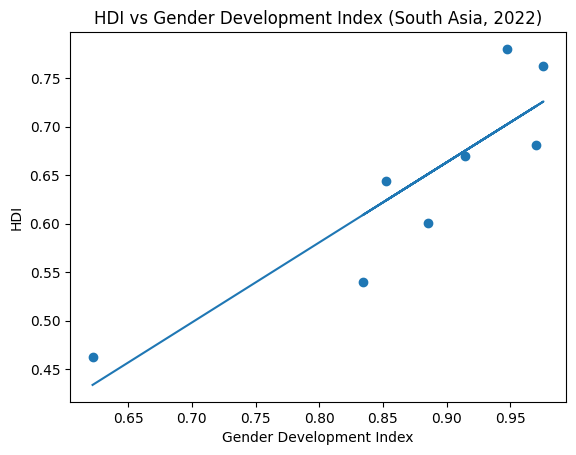

In [196]:
#Scatter plot: HDI vs Gender Development Index
plt.scatter(metric_df["gender_development"], metric_df["hdi"])
z = np.polyfit(metric_df["gender_development"], metric_df["hdi"], 1)
p = np.poly1d(z)
plt.plot(metric_df["gender_development"], p(metric_df["gender_development"]))

plt.title("HDI vs Gender Development Index (South Asia, 2022)")
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.show()


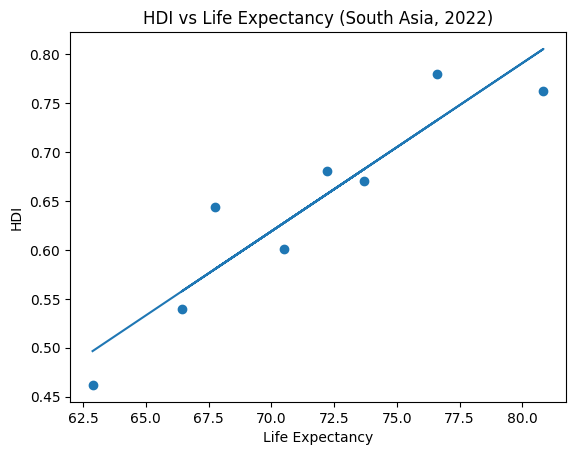

In [197]:
#Scatter plot: HDI vs Life Expectancy Index
plt.scatter(metric_df["life_expectancy"], metric_df["hdi"])
z = np.polyfit(metric_df["life_expectancy"], metric_df["hdi"], 1)
p = np.poly1d(z)
plt.plot(metric_df["life_expectancy"], p(metric_df["life_expectancy"]))

plt.title("HDI vs Life Expectancy (South Asia, 2022)")
plt.xlabel("Life Expectancy")
plt.ylabel("HDI")
plt.show()


**Discussion:**

The correlation results and scatter plots show that life expectancy has the strongest relationship with HDI, while the gender development index shows a comparatively weaker relationship. This is evident from the higher Pearson correlation value and the clearer linear trend observed for life expectancy.


Task 5: Gap Analysis

In [198]:
# Create the GNI_HD_Gap metric
south_asia_df['GNI_HD_Gap'] = south_asia_df['gross_inc_percap'] - south_asia_df['hdi']

# Display the first few rows to verify
print(south_asia_df[['country', 'gross_inc_percap', 'hdi', 'GNI_HD_Gap']].head())

       country  gross_inc_percap    hdi   GNI_HD_Gap
0  Afghanistan       3115.670448  0.284  3115.386448
1  Afghanistan       2817.304736  0.292  2817.012736
2  Afghanistan       2474.681985  0.299  2474.382985
3  Afghanistan       1723.019763  0.307  1722.712763
4  Afghanistan       1202.010488  0.300  1201.710488


In [199]:
# Rank countries by GNI_HD_Gap in descending order
ranked_desc = south_asia_df[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=False)

# Rank countries by GNI_HD_Gap in ascending order
ranked_asc = south_asia_df[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=True)

# Display the top few rankings in descending and ascending order
print("Top countries by GNI_HD_Gap (Descending):")
print(ranked_desc.head())

print("\nTop countries by GNI_HD_Gap (Ascending):")
print(ranked_asc.head())

Top countries by GNI_HD_Gap (Descending):
       country   GNI_HD_Gap
3530  Maldives  18846.03019
3527  Maldives  18679.17236
3526  Maldives  18054.97765
3525  Maldives  17473.90201
3524  Maldives  16910.72022

Top countries by GNI_HD_Gap (Ascending):
        country   GNI_HD_Gap
11  Afghanistan   980.789554
10  Afghanistan  1047.002686
9   Afghanistan  1121.985570
4   Afghanistan  1201.710488
8   Afghanistan  1226.964565


In [200]:
# Check the distribution of GNI_HD_Gap values
gap_description = south_asia_df['GNI_HD_Gap'].describe()
print("GNI_HD_Gap distribution summary:")
print(gap_description)

# Check for any extreme values
outliers_check = south_asia_df[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=False)
print("Top countries with extreme GNI_HD_Gap values:")
print(outliers_check.head())

# Check for the minimum GNI_HD_Gap
print("Countries with the smallest GNI_HD_Gap:")
print(outliers_check.tail(3))


GNI_HD_Gap distribution summary:
count      239.000000
mean      5492.275188
std       4381.877468
min        980.789554
25%       2228.749965
50%       3854.920519
75%       6832.884826
max      18846.030190
Name: GNI_HD_Gap, dtype: float64
Top countries with extreme GNI_HD_Gap values:
       country   GNI_HD_Gap
3530  Maldives  18846.03019
3527  Maldives  18679.17236
3526  Maldives  18054.97765
3525  Maldives  17473.90201
3524  Maldives  16910.72022
Countries with the smallest GNI_HD_Gap:
       country  GNI_HD_Gap
3500  Maldives         NaN
3501  Maldives         NaN
3502  Maldives         NaN


In [201]:
# Remove rows where GNI_HD_Gap is NaN
hdi_south_asia_df_cleaned = south_asia_df.dropna(subset=['GNI_HD_Gap'])

# Recalculate the rankings
ranked_desc_cleaned = hdi_south_asia_df_cleaned[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=False)
ranked_asc_cleaned = hdi_south_asia_df_cleaned[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=True)

# Get the top 3 positive gaps (highest GNI_HD_Gap)
top_3_positive_cleaned = ranked_desc_cleaned.head(3)

# Get the top 3 negative gaps (lowest GNI_HD_Gap)
top_3_negative_cleaned = ranked_asc_cleaned.head(3)

# Display the cleaned data for verification
print("Top 3 Positive Gaps after cleaning:")
print(top_3_positive_cleaned)

print("Top 3 Negative Gaps after cleaning:")
print(top_3_negative_cleaned)


Top 3 Positive Gaps after cleaning:
       country   GNI_HD_Gap
3530  Maldives  18846.03019
3527  Maldives  18679.17236
3526  Maldives  18054.97765
Top 3 Negative Gaps after cleaning:
        country   GNI_HD_Gap
11  Afghanistan   980.789554
10  Afghanistan  1047.002686
9   Afghanistan  1121.985570


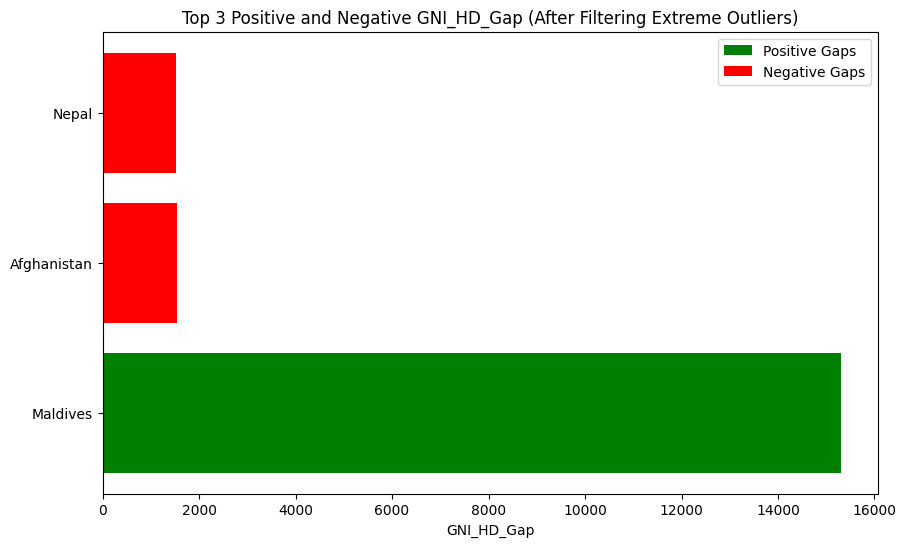

In [202]:
# Remove extreme outliers: Let's remove values outside the 5th and 95th percentiles
lower_percentile = south_asia_df['GNI_HD_Gap'].quantile(0.05)
upper_percentile = south_asia_df['GNI_HD_Gap'].quantile(0.95)

# Filter the dataset to only include rows within the 5th and 95th percentiles
filtered_df = south_asia_df[(south_asia_df['GNI_HD_Gap'] > lower_percentile) &
                                 (south_asia_df['GNI_HD_Gap'] < upper_percentile)]

# Recalculate the rankings after removing outliers
ranked_desc_filtered = filtered_df[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=False)
ranked_asc_filtered = filtered_df[['country', 'GNI_HD_Gap']].sort_values(by='GNI_HD_Gap', ascending=True)

# Get the top 3 positive gaps and top 3 negative gaps after filtering
top_3_positive_filtered = ranked_desc_filtered.head(3)
top_3_negative_filtered = ranked_asc_filtered.head(3)

# Plot the top 3 positive and top 3 negative gaps in a bar chart
plt.figure(figsize=(10, 6))

# Plot positive gaps (green)
plt.barh(top_3_positive_filtered['country'], top_3_positive_filtered['GNI_HD_Gap'], color='green', label='Positive Gaps')

# Plot negative gaps (red)
plt.barh(top_3_negative_filtered['country'], top_3_negative_filtered['GNI_HD_Gap'], color='red', label='Negative Gaps')

# Add labels and title
plt.xlabel('GNI_HD_Gap')
plt.title('Top 3 Positive and Negative GNI_HD_Gap (After Filtering Extreme Outliers)')
plt.legend()

# Display the plot
plt.show()


DISCUSSION

A high GNI with a low HDI indicates that economic growth is not translating into improvements in health or education. This could be due to factors like unequal wealth distribution, political instability, or insufficient investment in public services. Countries like Afghanistan and Nepal may have good economic indicators, but their populations face challenges in accessing quality healthcare and education, which limits their HDI. Similarly, Maldives shows a large positive gap, suggesting that despite its high income, the country may face challenges in human development areas, such as healthcare or education.

In essence, a high GNI without a corresponding HDI increase points to the need for better distribution of resources and investment in human development.

Problem 3: Comparative Regional Analysis — South Asia vs Middle East

Task 1: Create Middle East Subset

In [203]:
# Define the list of Middle East countries
middle_east_countries = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait",
                         "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia",
                         "Syria", "United Arab Emirates", "Yemen"]

# Print the list to check
print(middle_east_countries)


['Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait', 'Lebanon', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Syria', 'United Arab Emirates', 'Yemen']


In [204]:
south_asia_countries = [
    "Afghanistan","Bangladesh","Bhutan","India","Maldives","Nepal","Pakistan","Sri Lanka"
]

middle_east_countries = [
    "Bahrain","Iran","Iraq","Israel","Jordan","Kuwait","Lebanon","Oman","Palestine",
    "Qatar","Saudi Arabia","Syria","United Arab Emirates","Yemen"
]


In [205]:
# Load the dataset from Problem 1B (HDI for South Asia and Middle East)
hdi_problem1B_df = pd.read_csv('HDI problem1B.csv')

# Filter the South Asia subset using the list of South Asian countries
south_asia_subset = hdi_problem1B_df[hdi_problem1B_df['country'].isin(south_asia_countries)]

# Filter the Middle East subset using the list of Middle East countries
middle_east_subset = hdi_problem1B_df[hdi_problem1B_df['country'].isin(middle_east_countries)]

# Save the subsets to new CSV files
south_asia_subset.to_csv('HDI_SouthAsia_2020_2022.csv', index=False)
middle_east_subset.to_csv('HDI_MiddleEast_2020_2022.csv', index=False)

# Print the shape of the subsets to confirm the operation
print("South Asia Subset shape:", south_asia_subset.shape)
print("Middle East Subset shape:", middle_east_subset.shape)


South Asia Subset shape: (24, 30)
Middle East Subset shape: (33, 30)


In [206]:
#Save required CSV files
south_asia_subset.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_subset.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

print("Saved: HDI_SouthAsia_2020_2022.csv")
print("Saved: HDI_MiddleEast_2020_2022.csv")

Saved: HDI_SouthAsia_2020_2022.csv
Saved: HDI_MiddleEast_2020_2022.csv


Task 2: Descriptive Statistics

In [207]:
sa_stats = south_asia_subset["hdi"].agg(["mean","std"])
me_stats = middle_east_subset["hdi"].agg(["mean","std"])

stats_df = pd.DataFrame({"South Asia": sa_stats, "Middle East": me_stats})
stats_df

,South Asia,Middle East
mean,0.639583,0.788909
std,0.098273,0.141295


In [208]:
better_region = "Middle East" if me_stats["mean"] > sa_stats["mean"] else "South Asia"
better_region


'Middle East'

**Discussion:** Middle East has a higher average HDI than South Asia across 2020–2022 based on the mean values.


Task 3: Top and Bottom Performers

In [209]:
# Group by country and calculate the mean HDI for South Asia and Middle East
sa_country_avg = south_asia_subset.groupby("country")["hdi"].mean().sort_values(ascending=False)
me_country_avg = middle_east_subset.groupby("country")["hdi"].mean().sort_values(ascending=False)

# Get the top 3 and bottom 3 countries based on HDI
sa_top3 = sa_country_avg.head(3)
sa_bottom3 = sa_country_avg.tail(3)

me_top3 = me_country_avg.head(3)
me_bottom3 = me_country_avg.tail(3)

# Print the results
print(f"Top 3 countries in South Asia by HDI: \n{sa_top3}")
print(f"Bottom 3 countries in South Asia by HDI: \n{sa_bottom3}")
print(f"Top 3 countries in the Middle East by HDI: \n{me_top3}")
print(f"Bottom 3 countries in the Middle East by HDI: \n{me_bottom3}")

Top 3 countries in South Asia by HDI: 
country
Sri Lanka    0.780000
Maldives     0.750667
Bhutan       0.677667
Name: hdi, dtype: float64
Bottom 3 countries in South Asia by HDI: 
country
Nepal          0.595000
Pakistan       0.537667
Afghanistan    0.474333
Name: hdi, dtype: float64
Top 3 countries in the Middle East by HDI: 
country
United Arab Emirates    0.932667
Israel                  0.910667
Bahrain                 0.885333
Name: hdi, dtype: float64
Bottom 3 countries in the Middle East by HDI: 
country
Lebanon    0.730000
Iraq       0.667000
Yemen      0.426333
Name: hdi, dtype: float64


In [210]:
compare_df = pd.DataFrame({
    "South Asia - Top 3": sa_top3,
    "South Asia - Bottom 3": sa_bottom3,
    "Middle East - Top 3": me_top3,
    "Middle East - Bottom 3": me_bottom3
})

compare_df


,South Asia - Top 3,South Asia - Bottom 3,Middle East - Top 3,Middle East - Bottom 3
country,,,,
Afghanistan,NaN,0.474333,NaN,NaN
Bahrain,NaN,NaN,0.885333,NaN
Bhutan,0.677667,NaN,NaN,NaN
Iraq,NaN,NaN,NaN,0.667000
Israel,NaN,NaN,0.910667,NaN
Lebanon,NaN,NaN,NaN,0.730000
Maldives,0.750667,NaN,NaN,NaN
Nepal,NaN,0.595000,NaN,NaN
Pakistan,NaN,0.537667,NaN,NaN


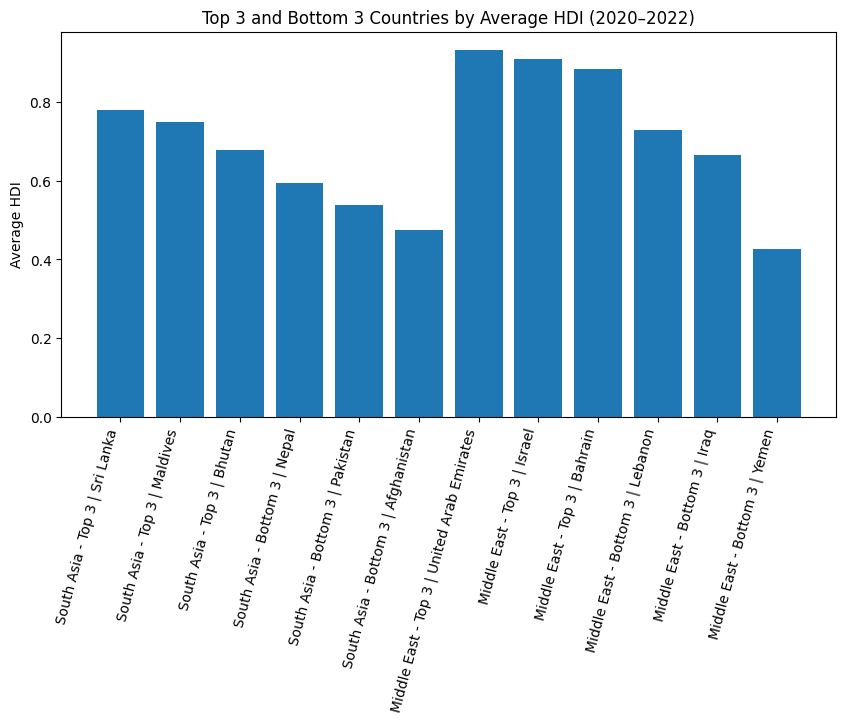

In [211]:
# Convert to long format for plotting
plot_data = []

for label, series in [
    ("South Asia - Top 3", sa_top3),
    ("South Asia - Bottom 3", sa_bottom3),
    ("Middle East - Top 3", me_top3),
    ("Middle East - Bottom 3", me_bottom3),
]:
    for country, val in series.items():
        plot_data.append((label, country, val))

plot_df = pd.DataFrame(plot_data, columns=["Group", "Country", "HDI"])

plt.figure(figsize=(10,5))
plt.bar(plot_df["Group"] + " | " + plot_df["Country"], plot_df["HDI"])
plt.xticks(rotation=75, ha="right")
plt.title("Top 3 and Bottom 3 Countries by Average HDI (2020–2022)")
plt.ylabel("Average HDI")
plt.show()


**Discussion:** The top performers have consistently higher HDI values across 2020–2022, while the bottom performers remain noticeably lower, showing a clear regional performance gap.


Task 4: Metric Comparisons

In [212]:
metrics = ["gender_development", "life_expectancy", "gross_inc_percap"]

sa_metric_means = south_asia_subset[metrics].mean()
me_metric_means = middle_east_subset[metrics].mean()

metric_compare = pd.DataFrame({
    "South Asia": sa_metric_means,
    "Middle East": me_metric_means
})

metric_compare

,South Asia,Middle East
gender_development,0.881458,0.896545
life_expectancy,70.970083,75.855455
gross_inc_percap,7766.509931,37750.770520


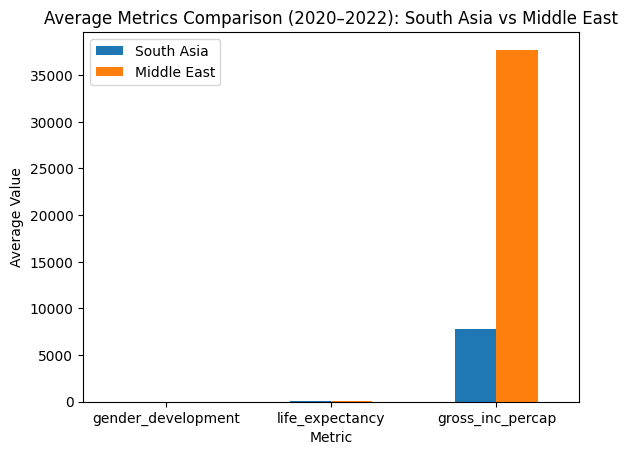

In [213]:
metric_compare.plot(kind="bar")
plt.title("Average Metrics Comparison (2020–2022): South Asia vs Middle East")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


In [214]:
metric_compare["Absolute Gap"] = (metric_compare["Middle East"] - metric_compare["South Asia"]).abs()
metric_compare.sort_values("Absolute Gap", ascending=False)


,South Asia,Middle East,Absolute Gap
gross_inc_percap,7766.509931,37750.770520,29984.260588
life_expectancy,70.970083,75.855455,4.885371
gender_development,0.881458,0.896545,0.015087


**Discussion:** Among the compared metrics, GNI per capita typically shows the greatest disparity between the two regions.


Task 5: HDI Disparity

In [215]:
# Compute the range (max - min) of HDI for South Asia
south_asia_hdi_range = south_asia_subset['hdi'].max() - south_asia_subset['hdi'].min()

# Compute the range (max - min) of HDI for Middle East
middle_east_hdi_range = middle_east_subset['hdi'].max() - middle_east_subset['hdi'].min()

# Print the results
print(f"HDI Range for South Asia: {south_asia_hdi_range}")
print(f"HDI Range for Middle East: {middle_east_hdi_range}")


HDI Range for South Asia: 0.321
HDI Range for Middle East: 0.5130000000000001


In [216]:
# Compute the coefficient of variation (CV) for HDI in South Asia
south_asia_hdi_cv = south_asia_subset['hdi'].std() / south_asia_subset['hdi'].mean()

# Compute the coefficient of variation (CV) for HDI in Middle East
middle_east_hdi_cv = middle_east_subset['hdi'].std() / middle_east_subset['hdi'].mean()

# Print the results
print(f"HDI Coefficient of Variation (CV) for South Asia: {south_asia_hdi_cv}")
print(f"HDI Coefficient of Variation (CV) for Middle East: {middle_east_hdi_cv}")


HDI Coefficient of Variation (CV) for South Asia: 0.1536520924690084
HDI Coefficient of Variation (CV) for Middle East: 0.17910145193048382


In [217]:
# Compare the results and identify which region has more variation in HDI
if south_asia_hdi_cv > middle_east_hdi_cv:
    print("South Asia exhibits more variation in HDI.")
else:
    print("Middle East exhibits more variation in HDI.")


Middle East exhibits more variation in HDI.


**Discussion:**

Based on the coefficient of variation, the Middle East exhibits greater variation in HDI compared to South Asia. This indicates that HDI values in the Middle East are more unevenly distributed, with a wider spread of development levels across countries.


Task 6: Correlation Analysis

In [147]:
# Compute correlation of HDI with Gender Development Index for South Asia
correlation_south_asia_gender = south_asia_subset['hdi'].corr(south_asia_subset['gender_development'])

# Compute correlation of HDI with Life Expectancy Index for South Asia
correlation_south_asia_life_expectancy = south_asia_subset['hdi'].corr(south_asia_subset['life_expectancy'])

# Compute correlation of HDI with Gender Development Index for Middle East
correlation_middle_east_gender = middle_east_subset['hdi'].corr(middle_east_subset['gender_development'])

# Compute correlation of HDI with Life Expectancy Index for Middle East
correlation_middle_east_life_expectancy = middle_east_subset['hdi'].corr(middle_east_subset['life_expectancy'])

# Print the correlations
print(f"South Asia HDI and Gender Development Index correlation: {correlation_south_asia_gender}")
print(f"South Asia HDI and Life Expectancy Index correlation: {correlation_south_asia_life_expectancy}")
print(f"Middle East HDI and Gender Development Index correlation: {correlation_middle_east_gender}")
print(f"Middle East HDI and Life Expectancy Index correlation: {correlation_middle_east_life_expectancy}")


South Asia HDI and Gender Development Index correlation: 0.8742177004831327
South Asia HDI and Life Expectancy Index correlation: 0.9387641385416623
Middle East HDI and Gender Development Index correlation: 0.9356697525724119
Middle East HDI and Life Expectancy Index correlation: 0.9331227568940162


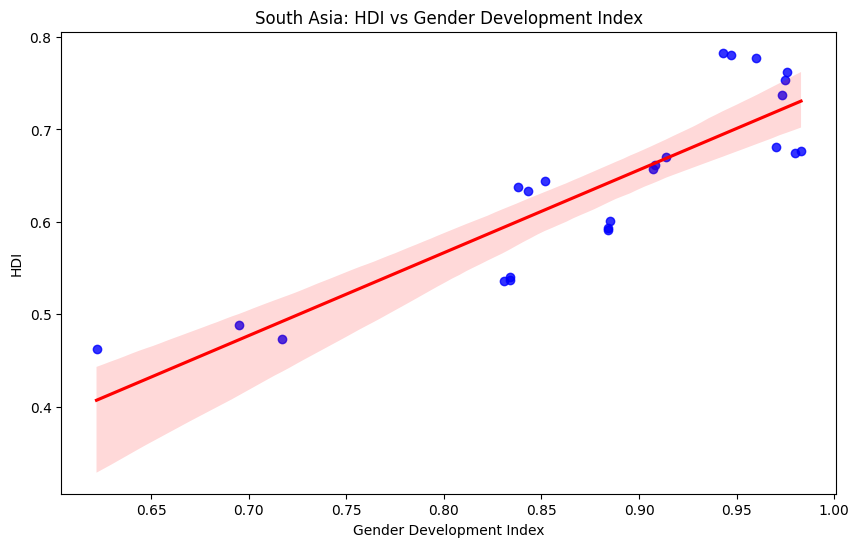

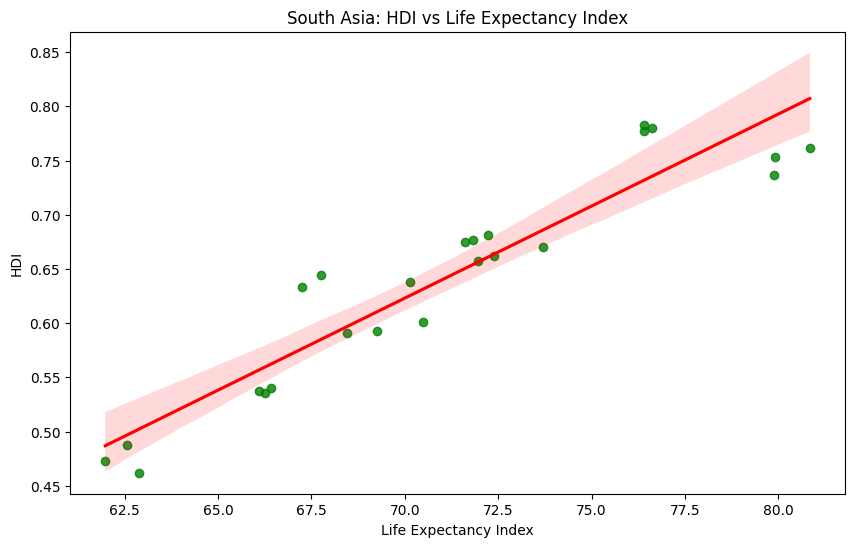

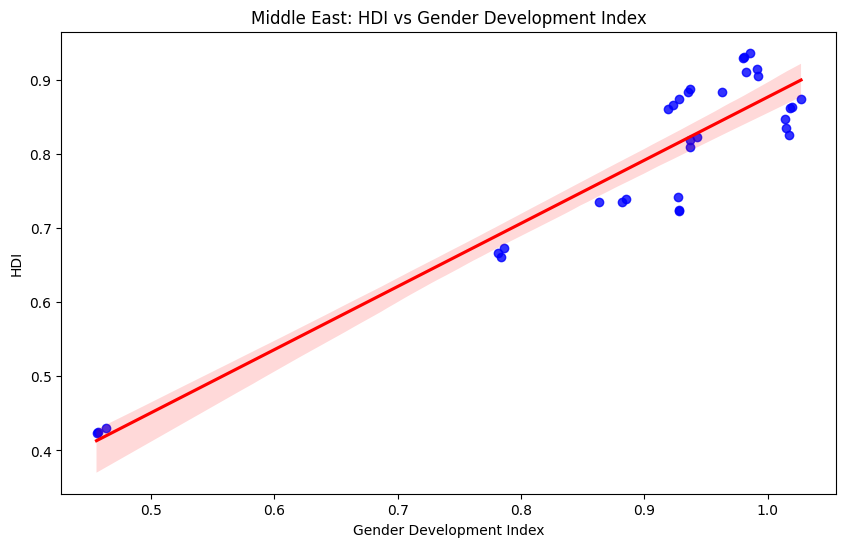

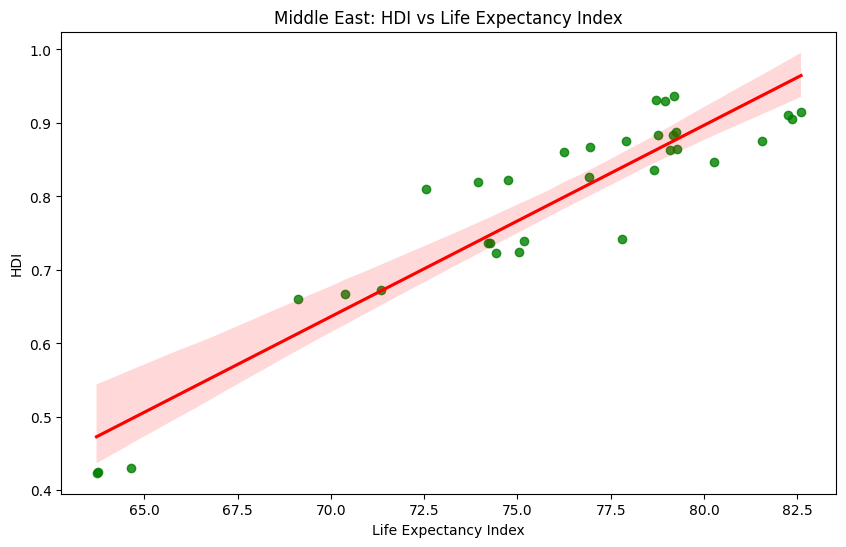

In [148]:
# Scatter plot for HDI vs Gender Development Index in South Asia
plt.figure(figsize=(10, 6))
sns.regplot(x='gender_development', y='hdi', data=south_asia_subset, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('South Asia: HDI vs Gender Development Index')
plt.xlabel('Gender Development Index')
plt.ylabel('HDI')
plt.show()

# Scatter plot for HDI vs Life Expectancy Index in South Asia
plt.figure(figsize=(10, 6))
sns.regplot(x='life_expectancy', y='hdi', data=south_asia_subset, scatter_kws={'color': 'green'}, line_kws={'color': 'red'})
plt.title('South Asia: HDI vs Life Expectancy Index')
plt.xlabel('Life Expectancy Index')
plt.ylabel('HDI')
plt.show()

# Scatter plot for HDI vs Gender Development Index in Middle East
plt.figure(figsize=(10, 6))
sns.regplot(x='gender_development', y='hdi', data=middle_east_subset, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Middle East: HDI vs Gender Development Index')
plt.xlabel('Gender Development Index')
plt.ylabel('HDI')
plt.show()

# Scatter plot for HDI vs Life Expectancy Index in Middle East
plt.figure(figsize=(10, 6))
sns.regplot(x='life_expectancy', y='hdi', data=middle_east_subset, scatter_kws={'color': 'green'}, line_kws={'color': 'red'})
plt.title('Middle East: HDI vs Life Expectancy Index')
plt.xlabel('Life Expectancy Index')
plt.ylabel('HDI')
plt.show()


**Discussion:** In both regions, HDI shows a positive relationship with gender development and life expectancy. The direction is positive, and life expectancy typically shows the stronger association with HDI.


Task 7: Outlier Detection

In [149]:
# Function to detect outliers using 1.5 * IQR rule
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers for HDI in South Asia
hdi_south_asia_outliers, hdi_lower, hdi_upper = detect_outliers(south_asia_subset, 'hdi')

# Detect outliers for GNI per Capita in South Asia
gni_south_asia_outliers, gni_lower, gni_upper = detect_outliers(south_asia_subset, 'gross_inc_percap')

# Detect outliers for HDI in Middle East
hdi_middle_east_outliers, hdi_lower_me, hdi_upper_me = detect_outliers(middle_east_subset, 'hdi')

# Detect outliers for GNI per Capita in Middle East
gni_middle_east_outliers, gni_lower_me, gni_upper_me = detect_outliers(middle_east_subset, 'gross_inc_percap')

# Print outliers for verification
print("South Asia HDI Outliers:")
print(hdi_south_asia_outliers[['country', 'hdi']])

print("South Asia GNI per Capita Outliers:")
print(gni_south_asia_outliers[['country', 'gross_inc_percap']])

print("Middle East HDI Outliers:")
print(hdi_middle_east_outliers[['country', 'hdi']])

print("Middle East GNI per Capita Outliers:")
print(gni_middle_east_outliers[['country', 'gross_inc_percap']])


South Asia HDI Outliers:
Empty DataFrame
Columns: [country, hdi]
Index: []
South Asia GNI per Capita Outliers:
Empty DataFrame
Columns: [country, gross_inc_percap]
Index: []
Middle East HDI Outliers:
    country    hdi
576   Yemen  0.430
577   Yemen  0.425
578   Yemen  0.424
Middle East GNI per Capita Outliers:
Empty DataFrame
Columns: [country, gross_inc_percap]
Index: []


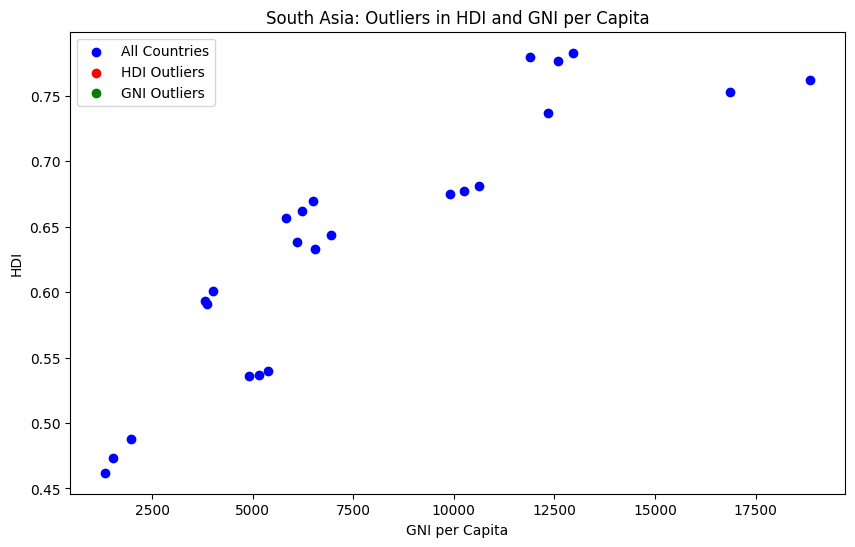

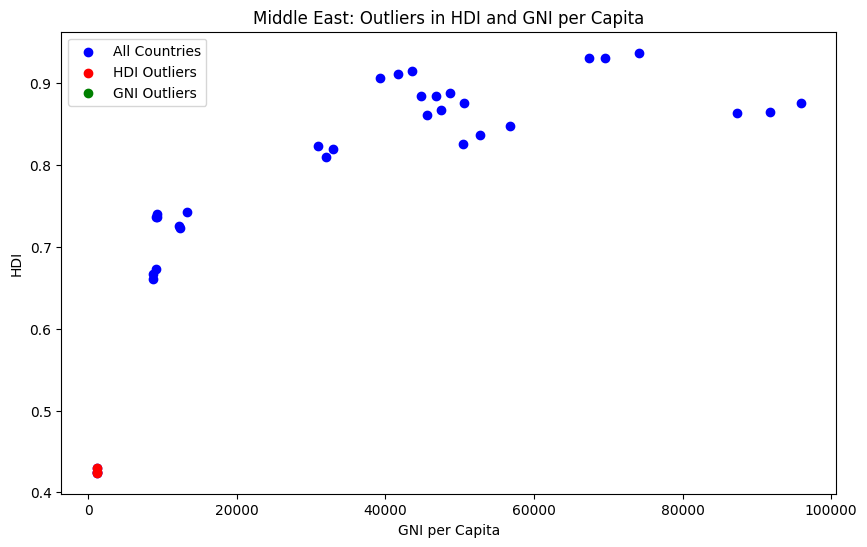

In [150]:
# Scatter plot for HDI vs GNI per Capita in South Asia
plt.figure(figsize=(10, 6))

# Plot all countries
plt.scatter(south_asia_subset['gross_inc_percap'], south_asia_subset['hdi'], color='blue', label='All Countries')

# Highlight outliers in red
plt.scatter(hdi_south_asia_outliers['gross_inc_percap'], hdi_south_asia_outliers['hdi'], color='red', label='HDI Outliers')
plt.scatter(gni_south_asia_outliers['gross_inc_percap'], gni_south_asia_outliers['hdi'], color='green', label='GNI Outliers')

# Labels and title
plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('South Asia: Outliers in HDI and GNI per Capita')
plt.legend()
plt.show()

# Scatter plot for HDI vs GNI per Capita in Middle East
plt.figure(figsize=(10, 6))

# Plot all countries
plt.scatter(middle_east_subset['gross_inc_percap'], middle_east_subset['hdi'], color='blue', label='All Countries')

# Highlight outliers in red
plt.scatter(hdi_middle_east_outliers['gross_inc_percap'], hdi_middle_east_outliers['hdi'], color='red', label='HDI Outliers')
plt.scatter(gni_middle_east_outliers['gross_inc_percap'], gni_middle_east_outliers['hdi'], color='green', label='GNI Outliers')

# Labels and title
plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('Middle East: Outliers in HDI and GNI per Capita')
plt.legend()
plt.show()


**Discussion:** The detected outliers represent countries whose HDI or GNI per capita values are unusually high or low compared to others in the same region, which can strongly influence averages and the spread of the data.
